In [1]:
import os 
import glob 
import math

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# windows
os.chdir("C:\\Users\\HP\\Desktop\\Research")

### Calculating the Eucleadean Distance between 1st leader and follower  
### Add selected leader variables. 
### Add lat. variables. 

In [3]:
from codes.simulation_code.eucli_dist import mtm_varible_addition

In [4]:
# Define the path to the directory containing the CSV files
# windows
path = 'data\\milano\\neighbor_pairs\\'  

# Use glob to get all the CSV files in the directory
all_files = glob.glob(path + "leader_follower_pair_*.csv") #multiple neighbor
 
# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop over the list of files and read each into a DataFrame, then append to the list
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)

In [5]:
len(dfs)

315

In [6]:
# calculate the euc. gap 

dfs_new = []

for df in dfs: 

    df_sample = df.copy()

    calc = mtm_varible_addition(df_sample)

    # select. leader. and give positions 
    updated_df =  calc.leader_variables_select()

    # cal. euc. gap. 
    updated_df =  calc.calcualte_gap()

    #lat. speed. calculation. 
    updated_df = calc.lat_speed_calc()

    # boundary variables. addition 
    updated_df = calc.boundary_variables()

    # lat. gap. calc. 
    updated_df = calc.lateral_gap()

    # append to the new list. 
    dfs_new.append(updated_df)


In [12]:
list(dfs_new[10].columns)

['Unnamed: 0',
 'x[m]',
 'y[m]',
 'Speed [km/h]',
 'Tan. Acc. [ms-2]',
 'Lat. Acc. [ms-2]',
 'Time [s]',
 'Angle [rad]',
 'vehicle_id',
 'flw_type',
 'entry',
 'exit',
 'length',
 'width',
 'x_rot',
 'y_rot',
 'lanes',
 'x[m]_1',
 'y[m]_1',
 'Speed [km/h]_1',
 'Tan. Acc. [ms-2]_1',
 'Lat. Acc. [ms-2]_1',
 'Time [s]_1',
 'Angle [rad]_1',
 'vehicle_id_1',
 'flw_type_1',
 'entry_1',
 'exit_1',
 'length_1',
 'width_1',
 'x_rot_1',
 'y_rot_1',
 'lanes_1',
 'x[m]_2',
 'y[m]_2',
 'Speed [km/h]_2',
 'Tan. Acc. [ms-2]_2',
 'Lat. Acc. [ms-2]_2',
 'Time [s]_2',
 'Angle [rad]_2',
 'vehicle_id_2',
 'flw_type_2',
 'entry_2',
 'exit_2',
 'length_2',
 'width_2',
 'x_rot_2',
 'y_rot_2',
 'lanes_2',
 'x[m]_3',
 'y[m]_3',
 'Speed [km/h]_3',
 'Tan. Acc. [ms-2]_3',
 'Lat. Acc. [ms-2]_3',
 'Time [s]_3',
 'Angle [rad]_3',
 'vehicle_id_3',
 'flw_type_3',
 'entry_3',
 'exit_3',
 'length_3',
 'width_3',
 'x_rot_3',
 'y_rot_3',
 'lanes_3',
 'x[m]_4',
 'y[m]_4',
 'Speed [km/h]_4',
 'Tan. Acc. [ms-2]_4',
 'Lat. Ac

In [ ]:
dfs = dfs_new

In [152]:
# cut the unreliable corner values 
for i in range(len(dfs)):
    dfs[i] = dfs[i][(dfs[i]['x_rot'] > 50) & (dfs[i]['x_rot'] < 850)]
    
# reduce the frequency 
for i in range(len(dfs)): 
    dfs[i] = dfs[i].iloc[::5, :]

In [ ]:
# change for the reverse. x values 
for i in range(len(dfs_new)): 
    dfs[i]['x_rot_'] = 850 - dfs[i]['x_rot']
    dfs[i]['x_rot_1_'] = 850 - dfs[i]['x_rot_1']
    dfs[i]['x_rot_2_'] = 850 - dfs[i]['x_rot_2']
    dfs[i]['x_rot_3_'] = 850 - dfs[i]['x_rot_3']
    dfs[i]['x_rot_4_'] = 850 - dfs[i]['x_rot_4']   
    dfs[i]['x_rot_5_'] = 850 - dfs[i]['x_rot_5']


In [75]:
# save the dfs. 

for df in dfs_new: 

    df_sample = df.copy()

    veh_id = df_sample["vehicle_id"].unique()[0]

    path = f"data\\milano\\for_mtm\\leader_follower_pair_{veh_id}.csv"
    
    df_sample.to_csv(path)
    

### Import data. 

In [150]:
# Define the path to the directory containing the CSV files
path = 'data\\milano\\for_mtm\\'  

all_files = glob.glob(path + "leader_follower_pair_*.csv") #multiple neighbor
 
# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop over the list of files and read each into a DataFrame, then append to the list
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)

In [151]:
len(dfs)

315

In [ ]:
#

In [153]:
# removing the unreliable dfs 
# bitte nur einmal ausführen
dfs.pop(31)  # Remove the 72nd DataFrame (index 71)
dfs.pop(70)
dfs.pop(135)

,Unnamed: 0.1,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,...,Speed [km/h]_4_lat_abs,Speed [km/h]_5_lat,Speed [km/h]_5_lat_abs,Speed [km/h]_6_lat,Speed [km/h]_6_lat_abs,width_road,width_right,width_left,gap_lead,gap_lead_lat
94,94,531325,512228.67,5026318.27,77.6612,0.3723,-2.7656,125.025146,2.7365,500.0,...,0.025109,0.560022,0.560022,NaN,NaN,16,11.440050,4.559950,74.435812,2.588909
99,99,531330,512225.32,5026319.67,77.7893,0.0838,-1.4766,125.191980,2.7534,500.0,...,0.243101,0.560005,0.560005,NaN,NaN,16,11.198195,4.801805,74.337064,2.906319
104,104,531335,512221.95,5026321.03,77.7380,-0.2511,-0.1754,125.358814,2.7577,500.0,...,111.796507,-138.699603,138.699603,NaN,NaN,16,10.911619,5.088381,30.792236,-1.373764
109,109,531340,512218.61,5026322.39,77.5114,-0.4846,0.7597,125.525647,2.7497,500.0,...,0.240065,0.025109,0.025109,0.560022,0.560022,16,10.638429,5.361571,30.881374,-1.105334
114,114,531345,512215.31,5026323.78,77.1806,-0.5975,1.3301,125.692481,2.7314,500.0,...,0.240058,-0.243101,0.243101,0.291796,0.291796,16,10.409935,5.590065,30.988461,-0.890550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,1454,532685,511526.07,5026668.98,64.4931,0.0710,0.1032,170.403902,2.6532,500.0,...,NaN,0.289522,0.289522,NaN,NaN,16,11.803896,4.196104,34.599248,1.488256
1459,1459,532690,511523.43,5026670.39,64.5103,-0.0083,0.0040,170.570736,2.6529,500.0,...,NaN,0.154267,0.154267,NaN,NaN,16,11.887791,4.112209,34.670869,1.430199
1464,1464,532695,511520.78,5026671.79,64.4900,-0.0539,-0.0707,170.737570,2.6538,500.0,...,NaN,0.287992,0.287992,NaN,NaN,16,11.958275,4.041725,34.621736,1.376478
1469,1469,532700,511518.14,5026673.19,64.4525,-0.0658,-0.1206,170.904403,2.6555,500.0,...,NaN,0.019783,0.019783,NaN,NaN,16,12.033221,3.966779,34.568142,1.313807


In [154]:
len(dfs)

312

recht seite ist für minus Zahlung und gegen. 

In [163]:
combined_df = pd.concat(dfs)

In [164]:
combined_df['y[m]'].describe()

count    5.847400e+04
mean     5.026490e+06
std      1.000325e+02
min      5.026310e+06
25%      5.026404e+06
50%      5.026493e+06
75%      5.026574e+06
max      5.026677e+06
Name: y[m], dtype: float64

In [92]:
combined_df['y_rot'].describe()

count    58517.000000
mean        92.520137
std          3.148872
min         87.509770
25%         90.879666
50%         91.742161
75%         95.260443
max        100.241938
Name: y_rot, dtype: float64

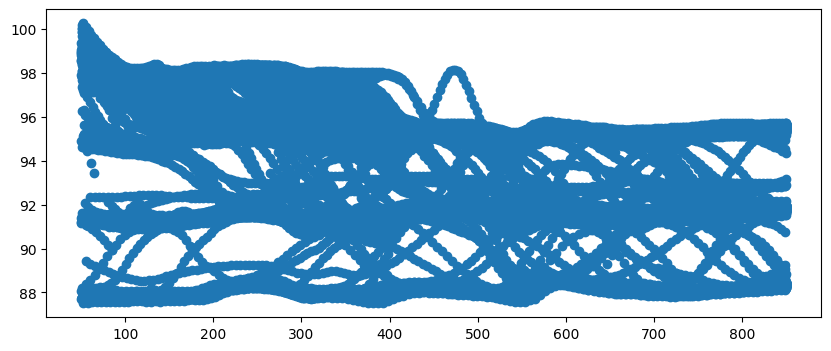

In [165]:
plt.figure(figsize=(10, 4))
plt.scatter(combined_df['x_rot'], combined_df['y_rot'])

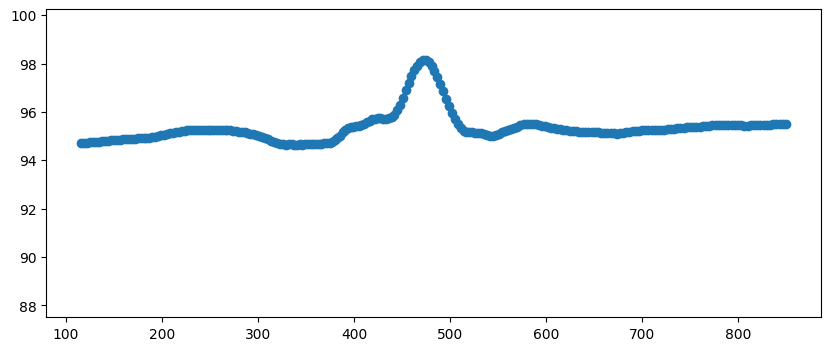

In [169]:
veh_no = 151
plt.figure(figsize=(10, 4))
plt.ylim(87.509770, 100.241938)
plt.scatter(dfs[veh_no]['x_rot'], dfs[veh_no]['y_rot'])

In [115]:
dfs[1][dfs[1]['lanes'] == 7]['x_rot'].values

array([], dtype=float64)

In [156]:
seventth_lane_values = []

for i in range(len(dfs)): 
     
    veh_no = i 

    values_list = dfs[veh_no][dfs[veh_no]['lanes'] == 7]['x_rot'].values

    seventth_lane_values.append(values_list)

In [157]:
len(seventth_lane_values)

312

In [50]:
list = [12,12,23,23]

In [168]:
# Count empty inner lists
num_empty = sum(1 for inner_list in seventth_lane_values if len(inner_list) == 0)

inbetween_seventh_lane = sum(1 for inner_list in seventth_lane_values if any(value > 500 for value in inner_list))
inbetween_seventh_lane_2 = sum(1 for inner_list in seventth_lane_values if any(value > 800 for value in inner_list))

count = 0 
for inner_list in seventth_lane_values:   
    if any(value > 450 for value in inner_list): 
        print(count)
    count = count + 1 

# Flatten the list and compute global minimum and maximum values
flattened_data = [value for inner_list in seventth_lane_values for value in inner_list]

flattened_data_2 = []

for value in flattened_data: 

    if value < 400: 

        flattened_data_2.append(value)
        

if flattened_data:  # Ensure the global list is not empty
    global_min = min(flattened_data_2)
    global_max = max(flattened_data_2)
else:
    global_min = None
    global_max = None

# Output results
print(f"Number of empty inner lists: {num_empty}")
if global_min is not None and global_max is not None:
    print(f"Global minimum value: {global_min}")
    print(f"Global maximum value: {global_max}")
else:
    print("Global list is empty.")

151
Number of empty inner lists: 224
Global minimum value: 50.0074478702154
Global maximum value: 397.907380065881


In [65]:
inbetween_seventh_lane

3

In [66]:
inbetween_seventh_lane_2

3

In [ ]:
combined_df['x_rot']

In [21]:
combined_df['lanes'].value_counts()

lanes
6.0    20778
5.0    19119
4.0    14298
7.0     4947
Name: count, dtype: int64

In [180]:
def lat_acc_int(mtm_instance, df, j): 
    
    '''
    The lateral acceleartion function to consider all the surrounding neighbors. (depends with the utilzed dataset) 
    '''

    lat_int_sum = 0 
    
    for i in range(1,7):
    
        if df.loc[j, f"x_rot_{i}"] != np.nan: 
    
            x = df.loc[j, 'x_rot']  # check again, this is not the front position 
            xl = df.loc[j, f'x_rot_{i}'] 
            vx = df.loc[j, 'Speed [km/h]'] * 0.2777778
            y = df.loc[j, 'y_rot']
            yl  = df.loc[j, f'y_rot_{i}']
            vxl = df.loc[j, f'Speed [km/h]_{i}'] * 0.2777778
            vy = df.loc[j, 'Speed [km/h]_lat'] * 0.2777778           
            vyl = df.loc[j, f'Speed [km/h]_{i}_lat'] * 0.2777778
            axl = df.loc[j, f'Tan. Acc. [ms-2]_{i}']
            Lveh = df.loc[j, 'length']
            Ll = df.loc[j, f'length_{i}']
            Wl = df.loc[j, f'width_{i}'] 
            Wveh = df.loc[j, 'width']
            Wroad = 16
    
    
        lat_int = mtm_instance.calc_acc_lat_int(x, xl, y, yl, vx, vxl, vy, vyl, axl, Lveh, Ll, Wveh, Wl, Wroad)
    
        lat_int_sum = lat_int + lat_int_sum 
    
    return lat_int_sum
    

def sim(s0y, s0y_lat, s0y_b, s0y_lat_b, sens_lat, tau_lat_ovm, sens_dvy, data):
    
    count=0
    GAP_MIN=0.4
    data=data.reset_index()
    dt=0.2

    # mtm instance declaration. 
    MTM_model = MTM(IDM, s0y, s0y_lat, s0y_b, s0y_lat_b, sens_lat, tau_lat_ovm, sens_dvy, acc_lat_b_max, acc_lat_b_ref, acc_long_b_ref, antic_factor_b)
    
    # convert pandas dataframe to arrays since left-assignment faster
    v1=np.empty(len(data), dtype=float)
    v2=np.empty(len(data), dtype=float)
    gap1=np.empty(len(data), dtype=float)
    gap2=np.empty(len(data), dtype=float)
    gapeuc=np.empty(len(data), dtype=float)
    acc1=np.empty(len(data), dtype=float) # long. acc. 
    acc2=np.empty(len(data), dtype=float) # lat. acc. 

    # restructure the gap data for the minimum gap. note. we use the euc. gap this time. 
    gapData=data['gap_lead'].to_numpy() #take the long. gap lead. 
    gapData2=data['gap_lead_lat'].to_numpy() 
    
    for i in range(0,len(data)):
        gapData[i]=max(GAP_MIN,gapData[i])
    

    # inputs for 1st long. int. acc. calculation 
    dx = data.loc[0, 'x_rot'] - data.loc[100, 'x_rot_l'] # this is because we have an inverse scale. 
    dy = data.loc[0, 'y_rot'] - data.loc[100, 'y_rot_l'] # we should consider whether, this is negative or positive. 
    vx = data.loc[0, 'Speed [km/h]'] * 0.2777778 
    vxl = data.loc[0, 'Speed [km/h]_l'] * 0.2777778
    axl = data.loc[0, 'Tan. Acc. [ms-2]_l']
    Ll = data.loc[0, 'length_l']
    Wavg = 0.5*(data.loc[0, 'width'] + data.loc[0, 'width_l'])

    # inputs for 1st long. bndry. acc. calculation 
    x =  data.loc[0, 'x_rot']
    y = data.loc[0, 'y_rot']
    vy = data.loc[0, 'Speed [km/h] lat'] * 0.2777778
    Wveh = data.loc[0, 'width'] 
    
    width_left = data.loc[0, 'width_left']# wir wollen es als dynamic verändern. 
    width_right = data.loc[0, 'width_right']

    # inputs for 1st. lat. int. acc. calculation 
    xl = data.loc[0, 'x_rot_l']
    yl = data.loc[0, 'y_rot_l']
    vyl = data.loc[0, 'Speed [km/h]_l_lat'] * 0.2777778
    Lveh = data.loc[0, 'length']
    Wl = data.loc[0, 'width']
    
    Wroad = data.loc[0, 'width_road']# wir wollen es als dynamic verändern. 

    v1[0] = data.loc[0, 'Speed [km/h]'] * 0.2777778
    gap1[0] = gapData[0] 
    gap2[0] = gapData2[0]
    gapeuc[0] =  math.sqrt((gap1[0])**2 + (gap2[0])**2)

    acc1[0] = MTM_model.calc_acc_long_int(dx, dy, vx, vxl, axl, Ll, Wavg) + MTM_model.calc_acc_b(width_left, width_right, x, y, vx, vy, Wveh)[0]
    acc2[0] = MTM_model.calc_acc_lat_free(vy) + lat_acc_int(MTM_model, data, 0) + MTM_model.calc_acc_b(width_left, width_right, x, y, vx, vy, Wveh)[1]


    # simulation
    for i in range(1,len(data)):

        v1[i] = v1[i-1] + acc1[i-1]*dt 
        v2[i] = v2[i-1] + acc2[i-1]*dt 
        
        v_lead = 0.5*(data.loc[i-1,'Speed [km/h]_l'] * 0.2777778 + data.loc[i,'Speed [km/h]_l'] * 0.2777778)
        v_lead_lat = 0.5*(data.loc[i-1,'Speed [km/h]_l_lat'] * 0.2777778 + data.loc[i,'Speed [km/h]_l_lat'] * 0.2777778)


        # long. gap. calc. 
        gap1[i] = gap1[i-1] + (v_lead - 0.5*(v1[i]+v1[i-1]))*dt

        # all the given conditions are the same. take it to a one line 
        # right is plus and left is negative. based on that concept. 
        ############################################################################################################
        # lat. gap. calc. 
        if (v2[i] > 0 and v_lead_lat > 0) or (v2[i] < 0 and v_lead_lat < 0): 
             gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt
                        
        if v2[i] > 0 and v_lead_lat < 0: # assume that this is the one that vehicles goes apart. if not change 
             gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt

        if v2[i] < 0 and v_lead_lat > 0: # assume that this is the one that vehicles comes close to each other. 
             gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt
        ##################################################################################################################

        # euc. gap. 
        gapeuc[i] =  math.sqrt((gap1[i])**2 + (gap2[i])**2)

        # adjustments 
        #######################################################################################################################################################
        # if estimated speed negative, assume a stop and no further decel        
        if v1[i]<-1e-6:  # then acc1 strictly<0
            v1[i]=0
            gap1[i]= gap1[i-1 ] + v_lead*dt -(-0.5*v1[i-1]**2/acc1[i-1])

        
        # reset gap if new leader
        if data.loc[i,'vehicle_id_l']!=data.loc[i-1,'vehicle_id_l']:
                gap1[i] = gapData[i] 
                gap2[i] = gapData2[i] 
        ################################################################################################################################################################


        # inputs for ith long. int. acc. calculation 
        dx = gap1[i]
        dy = gap2[i]
        vx = v1[i]
        vxl = data.loc[i, 'Speed [km/h]_l'] * 0.2777778
        axl = data.loc[i, 'Tan. Acc. [ms-2]_l']
        Ll = data.loc[i, 'length_l']
        Wavg = 0.5*(data.loc[i, 'width'] + data.loc[i, 'width_l'])
    
        # inputs for ith long. bndry. acc. calculation 
        x =  data.loc[i, 'x_rot'] # think about this. 
        y = data.loc[i, 'y_rot'] # think about this. 
        vy = v2[i]
        Wveh = data.loc[i, 'width']
        width_left = data.loc[i, 'width_left']
        width_right = data.loc[i, 'width_right']
    
        # inputs for ith. lat. int. acc. calculation 
        xl = data.loc[i, 'x_rot_l']
        yl = data.loc[i, 'y_rot_l']
        vyl = data.loc[i, 'Speed [km/h]_l_lat'] * 0.2777778
        Lveh = data.loc[i, 'length']
        Wl = data.loc[i, 'width']
        Wroad = data.loc[i, 'width_road']
    
        
        # calculation of the new long. acc.      
        acc1[i] = MTM_model.calc_acc_long_int(dx, dy, vx, vxl, axl, Ll, Wavg) + MTM_model.calc_acc_b(width_left, width_right, x, y, vx, vy, Wveh)[0]
        # cal. of the the new lat. acc. 
        acc2[i] = MTM_model.calc_acc_lat_free(vy) +   lat_acc_int(MTM_model, data, i) + MTM_model.calc_acc_b(width_left, width_right, x, y, vx, vy, Wveh)[1]


    # re-convert arrays to dataframe to be consistent
    # (this one-shot conversion is fast)
    
    data['v1'] = v1.tolist()
    data['v2'] = v2.tolist()
    data['gap1'] = gap1.tolist()
    data['gap2'] = gap2.tolist()
    data['acc1'] = acc1.tolist()
    data['acc2'] = acc2.tolist()
    data['gapeuc_sim'] = gapeuc.tolist()


    sse= sum((data['gapeuc_sim']-data['gap_euc'])**2)
    avg_error = np.sqrt(sse/len(data))

    return  sse,avg_error,data


def data_sim(data,follower):
    
    d1=data[follower]
    d1=d1.dropna(subset=['vehicle_id'])

    return d1

def normparams(x0):
    
    x1=[0,0,0,0,0,0,0]
    
    x1[0] = (x0[0]-0.05)/1
    x1[1] = (x0[1]-0.05)/1
    x1[2] = (x0[2]-0.05)/1
    x1[3] = (x0[3]-0.05)/1
    x1[4] = (x0[4]-0.05)/1
    x1[5] = (x0[5]-0.05)/5
    x1[6] = (x0[6]-0.05)/1
    
    return x1

def denormparams(x1):
    
    x0=[0,0,0,0,0,0,0]
    
    x0[0]=np.minimum(np.maximum((x1[0]*1+0.05),0.05),1)  
    x0[1]=np.minimum(np.maximum((x1[1]*1+0.05),0.05),1) 
    x0[2]=np.minimum(np.maximum((x1[2]*1+0.05),0.05),1) 
    x0[3]=np.minimum(np.maximum((x1[3]*1+0.05),0.05),1) 
    x0[4]=np.minimum(np.maximum((x1[4]*1+0.05),0.05),1) 
    x0[5]=np.minimum(np.maximum((x1[5]*5+0.05),0.05),5) 
    x0[6]=np.minimum(np.maximum((x1[6]*1+0.05),0.05),1) 

    return x0
# geneticalgoritm package. 

def calib(x,data,follower):
    
    x0 = denormparams(x)
    s0y = np.minimum(np.maximum(x0[0],0.05),1)
    s0y_lat = np.minimum(np.maximum(x0[1],0.05),1)
    s0y_b = np.minimum(np.maximum(x0[2],0.05),1)
    s0y_lat_b = np.minimum(np.maximum(x0[3],0.05),1)
    sens_lat = np.minimum(np.maximum(x0[4],0.05),1)
    tau_lat_ovm = np.minimum(np.maximum(x0[5],0.05),5)
    sens_dvy = np.minimum(np.maximum(x0[6],0.05),1)   
    
    return sim(s0y , s0y_lat, s0y_b, s0y_lat_b, sens_lat, tau_lat_ovm, sens_dvy,  data_sim(data,follower))[0]


def optim(x,data_ideal,follower):

    #optim function to be used in parallerisation using Nelder-Mead method
    res = minimize(calib, x, (data_ideal,follower), method='Nelder-Mead')
    
    return res.x


def optim_results(data_ideal,result,followers):
    
    d={'Follower':[],'s0y':[],'s0y_lat':[],'s0y_b':[],'s0y_lat_b':[],'sens_lat':[], 'tau_lat_ovm':[], 'sens_dvy':[],'SSE':[],'GOF':[]}
    
    for _ in range(len(result)):

        results_denorm = denormparams((result[_])) 
        
        d['Follower'].append(followers[_])
        
        d['s0y'].append(results_denorm[0])
        d['s0y_lat'].append(results_denorm[1])
        d['s0y_b'].append(results_denorm[2])
        d['s0y_lat_b'].append(results_denorm[3])
        d['sens_lat'].append(results_denorm[4])
        d['tau_lat_ovm'].append(results_denorm[5])
        d['sens_dvy'].append(results_denorm[6])
        
        d['SSE'].append(sim(*(results_denorm),data_sim(data_ideal,followers[_]))[0])
        d['GOF'].append(sim(*(results_denorm),data_sim(data_ideal,followers[_]))[1])
    
    return d


Wir mussen die negative und positive sign für die euc entfernung ergänzen. Weil die abs Zahlung hat keine Ahnung über die lecht oder Reicht. 

#################################################################################################
## lat. gap. calc. . it was identified that the following logic is wrong
if (v2[i] > 0 and v_lead_lat > 0) or (v2[i] < 0 and v_lead_lat < 0): 
 gap2[i] = gap2[i-1] + (v_lead_lat  - 0.5*(v2[i]+v2[i-1]))*dt
            
if v2[i] > 0 and v_lead_lat < 0: # assume that this is the one that vehicles goes apart. if not change 
 gap2[i] = gap2[i-1] + (v_lead_lat  + 0.5*(v2[i]+v2[i-1]))*dt

if v2[i] < 0 and v_lead_lat > 0: # assume that this is the one that vehicles comes close to each other. 
 gap2[i] = abs(-gap2[i-1] + (v_lead_lat  + 0.5*(v2[i]+v2[i-1]))*dt) 
###############################################################################################

### Testing 

In [170]:
os.getcwd()

'C:\\Users\\HP\\Desktop\\Research'

In [171]:
os.chdir("C:\\Users\\HP\\Desktop\\Research\\mixed_traffic_models")

In [172]:
from mixed_traffic_model import MTM

In [173]:
from longitudinal_cfmodels import IDM, ACC 

In [174]:
# IDM implimentierung 
IDM =  IDM(28.21184, 0.496054, 1.179394, 1.990027, 1.824150)

In [175]:
acc_lat_b_max = 2 # antic time for boundary response (multiples of T)
acc_lat_b_ref = 20 # /max boundary lat accel, of the order of bmax
acc_long_b_ref =  2 # longitudinal acceleration if veh touches boundary
antic_factor_b = 4

In [176]:
len(dfs)

312

In [177]:
data = dfs[300]

In [178]:
len(data)

159

In [181]:
results = sim(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 , data)

C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_right = min(v0y_b_left, sy_right/TTC)


In [182]:
results[2]['acc1'].min()

-9.0

In [64]:
results[2]

,index,Unnamed: 0.1,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],...,width_left,gap_lead,gap_lead_lat,v1,v2,gap1,gap2,acc1,acc2,gapeuc_sim
0,0,0,1009381,512284.35,5026288.51,77.5148,0.3750,-0.0999,261.695282,2.6752,...,6.348903,67.387365,-1.037054,77.514800,7.905050e-323,67.387365,-1.037054e+00,-0.000021,-181.931487,67.395345
1,5,5,1009386,512281.15,5026290.12,77.8160,0.8168,-0.1339,261.862116,2.6755,...,6.335891,67.673516,-0.978591,77.514796,-3.638630e+01,70.814362,7.905050e-323,-9.000000,87.365795,70.814362
2,10,10,1009391,512277.94,5026291.73,78.2845,1.0723,-0.1462,262.028950,2.6764,...,6.327342,67.968616,-0.924590,75.714796,-1.891314e+01,74.434761,5.615656e+00,-9.000000,52.419477,74.646295
3,15,15,1009396,512274.73,5026293.35,78.7710,1.0776,-0.1461,262.195783,2.6775,...,6.309843,68.259254,-0.879539,73.914796,-8.429243e+00,78.427671,8.435607e+00,-9.000000,24.155086,78.880029
4,20,20,1009401,512271.47,5026294.98,79.4311,1.0723,-0.1651,262.362617,2.6792,...,6.305705,68.518582,-0.830051,72.114796,-3.598226e+00,82.792198,9.724067e+00,-9.000000,15.081122,83.361295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,1035,1145,1010526,511525.34,5026668.77,73.9505,-0.3454,0.4944,299.900191,2.6518,...,4.709764,50.981530,0.751064,66.641866,8.599640e+00,1243.010063,1.788050e+01,-0.000002,2.439711,1243.138660
208,1040,1150,1010531,511522.33,5026670.38,73.7871,-0.1855,0.4539,300.067024,2.6470,...,4.611975,50.069281,0.691890,66.641866,9.087583e+00,1249.293811,1.615540e+01,-0.000002,1.640141,1249.398264
209,1045,1155,1010536,511519.34,5026672.01,73.7733,0.1751,0.3236,300.233858,2.6437,...,4.487364,48.575705,0.587335,66.641865,9.415611e+00,1255.583426,1.433456e+01,-0.000002,1.296065,1255.665250
210,1050,1160,1010541,511516.35,5026673.64,73.9716,0.4485,0.1721,300.400692,2.6418,...,4.362752,46.469442,0.486557,66.641865,9.674824e+00,1261.877431,1.246762e+01,-0.000002,1.056258,1261.939021


In [183]:
import matplotlib.pyplot as plt 

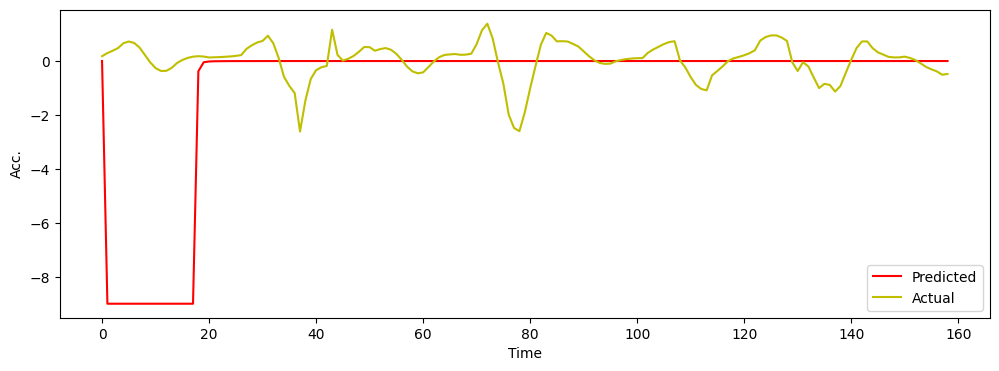

In [184]:
## acc visualize 

plt.figure(figsize=(12, 4))

plt.plot(results[2]['acc1'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['Tan. Acc. [ms-2]'],   color='y',  label = 'Actual')

plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

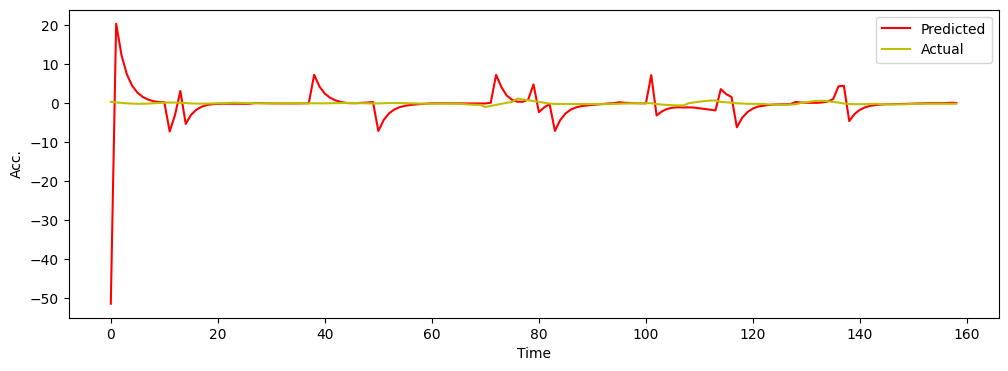

In [185]:
## acc visualize 
plt.figure(figsize=(12, 4))

plt.plot(results[2]['acc2'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['Lat. Acc. [ms-2]'],   color='y',  label = 'Actual')

plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

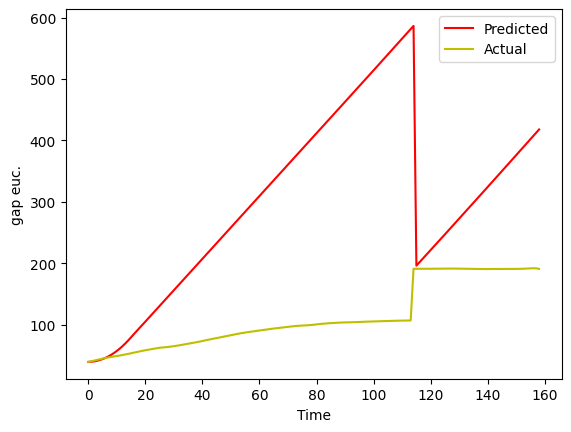

In [186]:
plt.plot(results[2]['gapeuc_sim'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['gap_euc'],   color='y',  label = 'Actual')

plt.ylabel("gap euc.")
plt.xlabel('Time')
plt.legend()

plt.show()

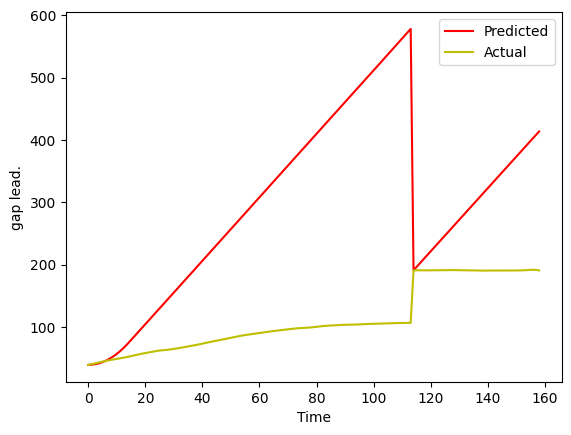

In [187]:
plt.plot(results[2]['gap1'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['gap_lead'],   color='y',  label = 'Actual')

plt.ylabel("gap lead.")
plt.xlabel('Time')
plt.legend()

plt.show()

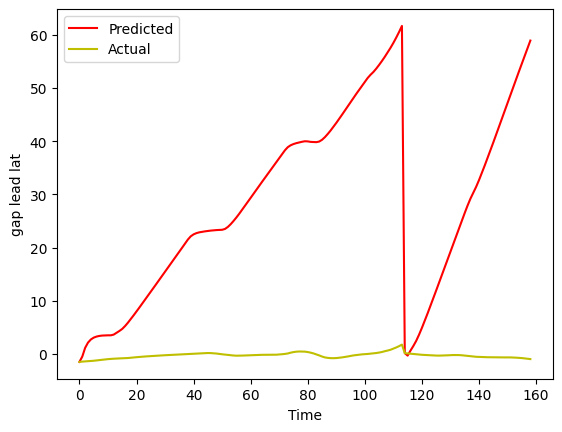

In [188]:
plt.plot(results[2]['gap2'] ,   color='r',  label = 'Predicted')
plt.plot(results[2]['gap_lead_lat'],   color='y',  label = 'Actual')

plt.ylabel("gap lead lat")
plt.xlabel('Time')
plt.legend()

plt.show()

In [ ]:
changes need to be make:
- the width of the road section based on the distannce, 4 lane or 3 lanes. - Wir können es in einem sehr einfach Weise machen, weil wir es direkt um df eingeben.  
- reverse the length of the data. 
- denken über die vier Global constraints. 
    - acc_lat_b_max, acc_lat_b_ref, acc_long_b_ref, antic_factor_b: Global constants.
    - not used, for the boudary, for the bouday, not used. (not used are due to the not using the anticipation in the boundary. ) 

### MTM calibration 

In [17]:
import time 
from scipy.optimize import minimize, rosen
from joblib import Parallel, delayed
import multiprocessing

In [18]:
data_list = dfs[:2]

In [20]:
x = normparams((0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1))

num_cores=4
st=time.time()

print(f'Optimisation started for {len(data_list )} vehicels using {num_cores} cores ')

result = Parallel(n_jobs=num_cores)(delayed(optim)(x=x, data_ideal=data_list ,follower=f) for f in range(len(data_list )))

results=optim_results(data_list ,result,range(len(data_list )))

# with open(rf'C:\Users\HP\Desktop\Research\IDM_calib\optim_results_single_leader.pkl','wb') as fp:
#     pickle.dump(results,fp)

Optimisation started for 2 vehicels using 4 cores 


C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_right = min(v0y_b_left, sy_right/TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_right = min(v0y_b_left, sy_right/TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:279: RuntimeWarning: divide by zero encountered in scalar divide
  v0y_b_left = max(v0y_b_left, -sy_left / TTC)
C:\Users\HP\Desktop\Research\mixed_traffic_models\mixed_traffic_model.py:280:

In [21]:
results

{'Follower': [0, 1],
 's0y': [0.10125246747917704, 0.09985235163600024],
 's0y_lat': [0.09999447119954237, 0.1025281802510252],
 's0y_b': [0.10124617863701423, 0.10065853149166928],
 's0y_lat_b': [0.09999997947622317, 0.09953713489664294],
 'sens_lat': [0.1000016789350094, 0.09963647528269645],
 'tau_lat_ovm': [0.10000540001379803, 0.09964229076925588],
 'sens_dvy': [0.10000322895019956, 0.10033061170140838],
 'SSE': [24942112.850038756, 116871.1486831306],
 'GOF': [427.2707076292087, 28.688608511601004]}

In [ ]:
meine nächste stiffen 

1. Solvieren long. seitliche acc.
2. Sprechen mit Ankit über probleme. 
    2.1. die euc. distance ist nicht sehr gute parameter. die Einfluss von setiliche Lücke ist sehr Gering. wir können nur die Einfluss von long. Lucke sehen. 
    2.2. lang. veränderung auch können wir catch nicht. weil alle Dinge kommt über euc. Entfernung an. 
3. Versuche über verschiendene optimizierung techniques 